<a href="https://colab.research.google.com/github/miriamamin1213-ux/HPV-classification/blob/main/Copy_of_CNNwith2CL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel("HPVCNN2.xlsx")  # or whatever filename appears

print(df.head())

print(df.columns)

  PatientID  CenterID  Task 1  Task 2  Task 3   Age  Gender  \
0  CHUM-001         1       1       1       0  82.0       1   
1  CHUM-002         1       1       1       0  73.0       1   
2  CHUM-006         1       1       1       0  65.0       1   
3  CHUM-007         1       1       1       0  70.0       0   
4  CHUM-008         1       1       1       0  67.0       0   

   Tobacco Consumption  Alcohol Consumption  Performance Status  Treatment  \
0                  NaN                  NaN                 NaN        1.0   
1                  NaN                  NaN                 NaN        1.0   
2                  NaN                  NaN                 NaN        1.0   
3                  NaN                  NaN                 NaN        0.0   
4                  NaN                  NaN                 NaN        1.0   

  T-stage N-stage M-stage  HPV Status  Relapse     RFS  
0      T2      N2      M0         NaN      0.0  1704.0  
1      T3      N2      M0         NaN 

In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("HPVCNN2.xlsx")

df.head()

,PatientID,CenterID,Task 1,Task 2,Task 3,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,T-stage,N-stage,M-stage,HPV Status,Relapse,RFS
0,CHUM-001,1,1,1,0,82.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1704.0
1,CHUM-002,1,1,1,0,73.0,1,NaN,NaN,NaN,1.0,T3,N2,M0,NaN,1.0,439.0
2,CHUM-006,1,1,1,0,65.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1186.0
3,CHUM-007,1,1,1,0,70.0,0,NaN,NaN,NaN,0.0,T2,N2,M0,NaN,0.0,1702.0
4,CHUM-008,1,1,1,0,67.0,0,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1499.0


In [ ]:
print(df.columns)

Index(['PatientID', 'CenterID', 'Task 1', 'Task 2', 'Task 3', 'Age', 'Gender',
       'Tobacco Consumption', 'Alcohol Consumption', 'Performance Status',
       'Treatment', 'T-stage', 'N-stage', 'M-stage', 'HPV Status', 'Relapse',
       'RFS'],
      dtype='object')


In [ ]:
df = df.dropna(
    subset=["HPV Status"]
)

In [ ]:
df["Tobacco Consumption"] = df[
    "Tobacco Consumption"
].fillna(0)

df["Alcohol Consumption"] = df[
    "Alcohol Consumption"
].fillna(0)

df["Performance Status"] = df[
    "Performance Status"
].fillna(0)

df["Treatment"] = df[
    "Treatment"
].fillna(0)

In [ ]:
t_map = {
    "T0":0,
    "T1":1,
    "T2":2,
    "T3":3,
    "T4":4
}

df["T-stage"] = df[
    "T-stage"
].map(t_map)

In [ ]:
n_map = {
    "N0":0,
    "N1":1,
    "N2":2,
    "N3":3
}

df["N-stage"] = df[
    "N-stage"
].map(n_map)

In [ ]:
m_map = {
    "M0":0,
    "M1":1
}

df["M-stage"] = df[
    "M-stage"
].map(m_map)

In [ ]:
features = [
    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Treatment",
    "T-stage",
    "N-stage"
]

X = df[features]

y = df["HPV Status"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [ ]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
print(pd.DataFrame(X_train_final).isna().sum())

0    0
1    0
2    0
3    0
4    0
5    0
6    3
7    2
dtype: int64


In [ ]:
print(df["T-stage"].unique())
print(df["N-stage"].unique())

[ 2.  4.  3.  1. nan  0.]
[ 1.  2.  3.  0. nan]


In [ ]:
df["T-stage"] = df["T-stage"].fillna(0)

df["N-stage"] = df["N-stage"].fillna(0)

df["M-stage"] = df["M-stage"].fillna(0)

In [ ]:
features = [
    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Treatment",
    "T-stage",
    "N-stage"
]

X = df[features]

y = df["HPV Status"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
print(pd.DataFrame(X_train_final).isna().sum())

0    0
1    0
2    0
3    0
4    0
5    0
6    3
7    2
dtype: int64


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


In [ ]:
import torch

X_train_smote = torch.tensor(
    X_train_smote,
    dtype=torch.float32
)


X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_smote = torch.tensor(
    y_train_smote,
    dtype=torch.long
)


y_test = torch.tensor(
    y_test.values,
    dtype=torch.long
)

In [ ]:
X_train_smote = X_train_smote.unsqueeze(1)

X_test = X_test.unsqueeze(1)

print(X_train_smote.shape)
print(X_test.shape)

torch.Size([848, 1, 8])
torch.Size([118, 1, 8])


In [ ]:
import torch.nn as nn

class HPVCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv1d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            32 * 8,
            32
        )

        self.fc2 = nn.Linear(
            32,
            2
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)

        x = self.flatten(x)

        x = self.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x


In [ ]:
model = HPVCNN()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
print(X_train_smote.shape)
print(X_test.shape)

torch.Size([848, 1, 8])
torch.Size([118, 1, 8])


In [ ]:
import torch.nn as nn

class HPVCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            16 * 8,
            32
        )

        self.fc2 = nn.Linear(
            32,
            2
        )

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.flatten(x)

        x = self.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x

In [ ]:
model = HPVCNN()

weights = torch.tensor(
    [2.0, 1.0],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
train_losses = []

test_losses = []

epochs = 500

best_val_loss = float('inf')

best_epoch = 0

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_smote)

    train_loss = criterion(
        outputs,
        y_train_smote
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        test_outputs = model(X_test)

        test_loss = criterion(
            test_outputs,
            y_test
        )

    train_losses.append(
        train_loss.item()
    )

    test_losses.append(
        test_loss.item()
    )

    if test_loss.item() < best_val_loss:

        best_val_loss = test_loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_cnn_model.pth"
        )

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch+1}, "
            f"Train={train_loss.item():.4f}, "
            f"Test={test_loss.item():.4f}"
        )

print("Best Test Loss =", best_val_loss)

print("Best Epoch =", best_epoch)

Epoch 50, Train=0.6116, Test=0.8177
Epoch 100, Train=0.5738, Test=0.8042
Epoch 150, Train=0.5317, Test=0.7817
Epoch 200, Train=0.4888, Test=0.7557
Epoch 250, Train=0.4517, Test=0.7372
Epoch 300, Train=0.4217, Test=0.7280
Epoch 350, Train=0.3977, Test=0.7225
Epoch 400, Train=0.3767, Test=0.7226
Epoch 450, Train=0.3586, Test=0.7244
Epoch 500, Train=0.3435, Test=0.7272
Best Test Loss = 0.7213318943977356
Best Epoch = 373


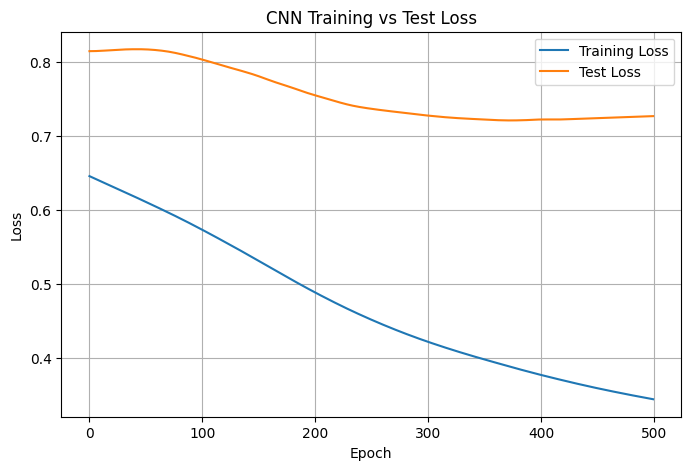

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label='Training Loss'
)

plt.plot(
    test_losses,
    label='Test Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title(
    'CNN Training vs Test Loss'
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
model.load_state_dict(
    torch.load(
        "best_cnn_model.pth"
    )
)

<All keys matched successfully>

In [ ]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    predicted = torch.argmax(
        outputs,
        dim=1
    )

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.19      0.83      0.30        12
           1       0.97      0.58      0.73       106

    accuracy                           0.61       118
   macro avg       0.58      0.71      0.52       118
weighted avg       0.89      0.61      0.69       118



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)

print(cm)

[[10  2]
 [44 62]]


In [ ]:
from sklearn.metrics import roc_auc_score

with torch.no_grad():

    outputs = model(X_test)

    probs = torch.softmax(
        outputs,
        dim=1
    )

    hpv_positive_probs = probs[:,1]

auc = roc_auc_score(
    y_test.numpy(),
    hpv_positive_probs.numpy()
)

print("AUC =", auc)

AUC = 0.7122641509433962
